# Single-mode reduction: the bright A exciton

This notebook isolates the **lowest pole** of the dressed exciton interaction of the polarized two-layer model (`Static_D.ipynb`) and builds its effective single-boson description. That pole is the bright intralayer (A) exciton: the lowest bound state of the **symmetric layer-pair sector**.

For a fixed magnetic angle $\theta$ we extract, from the full continuum bubble:

- the mode energy $E_X(\theta)$ (pole of $D^R$),
- the mode vector $|X(\theta)\rangle$ in the (intra$_s$, CT$_s$) channel basis,
- the residue $Z_X(\theta)$,
- the charge-transfer admixture $|\langle{\rm CT}_s|X\rangle|^2$.

Near the pole the channel-space propagator collapses to a single boson,

$$D^R_s(\Omega;\theta)\simeq\frac{Z_X(\theta)\,|X(\theta)\rangle\langle X(\theta)|}{\Omega-E_X(\theta)+i\eta},$$

and we verify this against the exact projection $\langle X|D^R_s|X\rangle$ and against the scalar BSE built from the **mode bubble** $\Pi_X(\Omega)=\langle X|\Pi_s(\Omega)|X\rangle$.

Parameters are the calibrated CrSBr set of `Static_D.ipynb`: bright exciton at $1.360$ eV (AFM) with a $15$ meV red-shift to FM (arXiv:2409.18501), coupling and interaction ratios from Heissenbuettel et al., PRB 111, 075107 (2025).

In [62]:
using LinearAlgebra
using Printf
using PyPlot

rc("font", family="serif")
rc("font", size=13)
rc("axes", labelsize=14, titlesize=14)
rc("legend", fontsize=10)

# -----------------------------
# Calibrated parameters (eV) -- same set as Static_D.ipynb:
# bright A exciton at 1.360 eV (AFM), 15 meV red-shift to FM.
# -----------------------------
L = 200                         # momentum points
γ_c = 0.40                      # conduction hopping (continuum scale A = 2(γc+γv) = 1.6 eV)
γ_v = 0.40                      # valence hopping
Δ_0 = 2.0                       # FM bare gap at k=0
Jpd_v = 0.069                   # valence/hole coupling (t_h)
Jpd_c = 0.031                   # conduction/electron coupling (t_e)
V_intra = 1.708                 # intralayer attraction |11>, |22>
V_inter = 0.691                 # interlayer/CT attraction |12>, |21>

T = 0.01
μchem = Δ_0 / 2
ηΩ = 0.005                       # broadening for Ω-resolved spectra; mode search uses η = 0

# Frequency window around the mode (~1.34-1.36) and the continuum onset (2.0-2.1).
Ωmin, Ωmax, NΩ = 1.25, 2.45, 681
ks = collect(range(-π, stop=π - 2π/L, length=L))
Ωs = collect(range(Ωmin, Ωmax, length=NΩ));

## Model and symmetric-sector reduction

The one-particle blocks are the same as in `Static_D`:

$$H_v(k,\theta)=-(\epsilon_v+2\gamma_v+J_{v\theta})\sigma_0+J_{v\theta}\sigma_x,\qquad
H_c(k,\theta)=\left[\epsilon_c+2\gamma_c+\Delta_0+(J_{pd,c}+J_{pd,v})(1-c_\theta)+J_{c\theta}\right]\sigma_0-J_{c\theta}\sigma_x,$$

with $c_\theta=\cos(\theta/2)$, $J_{v\theta}=J_{pd,v}c_\theta$, $J_{c\theta}=J_{pd,c}c_\theta$.

Layer-swap symmetry block-diagonalizes the four layer-pair channels into symmetric and antisymmetric sectors. The bright exciton lives in the **symmetric sector**, spanned by

$$|{\rm intra}_s\rangle=\tfrac{1}{\sqrt2}(|11\rangle+|22\rangle),\qquad
|{\rm CT}_s\rangle=\tfrac{1}{\sqrt2}(|12\rangle+|21\rangle),$$

with sector vertices $\Gamma_{\rm intra}=\sigma_0/\sqrt2$ and $\Gamma_{\rm CT}=\sigma_x/\sqrt2$ in layer space, and sector interaction

$$V_s=-{\rm diag}(V_{\rm intra},V_{\rm inter}).$$

The $2\times2$ sector bubble is the Lehmann sum

$$\Pi^s_{\alpha\beta}(\Omega)=\frac{1}{L}\sum_{k,a,b}
\frac{f(E^v_{bk})-f(E^c_{ak})}{\Omega+i\eta-(E^c_{ak}-E^v_{bk})}\,
m^\alpha_{ab}(k)\,m^{\beta*}_{ab}(k),\qquad m^\alpha_{ab}=\langle u^c_a|\Gamma_\alpha|u^v_b\rangle.$$

Both sector vertices are diagonal in the parity ($\pm$) band basis, so only the $(c_\pm,v_\pm)$ transitions contribute. We precompute the transition list once per angle and reuse it for every $\Omega$.

In [44]:
# -----------------------------
# Model, transition data, sector bubble
# -----------------------------
σ_0 = ComplexF64[1 0; 0 1]
σ_x = ComplexF64[0 1; 1 0]
ϵk(k, γ) = -2γ * cos(k)

function H_valence(k, θ)
    εv = ϵk(k, γ_v)
    Jvθ = Jpd_v * cos(θ/2)
    return -(εv + 2γ_v + Jvθ) * σ_0 + Jvθ * σ_x
end

function H_conduction(k, θ)
    εc = ϵk(k, γ_c)
    cθ = cos(θ/2)
    Jcθ = Jpd_c * cθ
    return (εc + 2γ_c + Δ_0 + (Jpd_c + Jpd_v) * (1 - cθ) + Jcθ) * σ_0 - Jcθ * σ_x
end

fermi(E) = 1 / (exp(clamp((E - μchem) / T, -60, 60)) + 1)

# Symmetric-sector vertices (intra_s, CT_s) and interaction.
Γ_sector = [σ_0/√2, σ_x/√2]
sector_labels = ["intra_s", "CT_s"]
V_s = Diagonal(ComplexF64[-V_intra, -V_inter])
Vinv_s = Matrix(inv(V_s))

# Flattened interband transition list at fixed angle: energies, occupations,
# and vertex weight matrices w[α,β,t] = m_α m_β*.
function sector_data(θ; ks=ks)
    nt = 4 * length(ks)
    ΔE = zeros(nt); occ = zeros(nt); w = zeros(ComplexF64, 2, 2, nt)
    t = 0
    for k in ks
        Fv = eigen(Hermitian(H_valence(k, θ)))
        Fc = eigen(Hermitian(H_conduction(k, θ)))
        m = [Fc.vectors' * Γ * Fv.vectors for Γ in Γ_sector]
        for a in 1:2, b in 1:2
            t += 1
            ΔE[t] = Fc.values[a] - Fv.values[b]
            occ[t] = fermi(Fv.values[b]) - fermi(Fc.values[a])
            for α in 1:2, β in 1:2
                w[α, β, t] = m[α][a, b] * conj(m[β][a, b])
            end
        end
    end
    return (; ΔE, occ, w, L=length(ks))
end

function Πs(data, Ω; η=0.0)
    Π = zeros(ComplexF64, 2, 2)
    for t in eachindex(data.ΔE)
        c = data.occ[t] / (Ω + 1im * η - data.ΔE[t])
        @views Π .+= c .* data.w[:, :, t]
    end
    return Π ./ data.L
end

# ∂Π/∂Ω at η = 0 (real Ω below the continuum), used for the residue.
function ∂Πs(data, Ω)
    Π = zeros(ComplexF64, 2, 2)
    for t in eachindex(data.ΔE)
        c = -data.occ[t] / (Ω - data.ΔE[t])^2
        @views Π .+= c .* data.w[:, :, t]
    end
    return Π ./ data.L
end;

## Mode extraction

The exciton is the lowest root of the pole condition

$$\det\left[V_s^{-1}-\Pi^R_s(E_X)\right]=0.$$

Below the continuum $\Pi_s(\Omega)$ is Hermitian (set $\eta=0$) and $\partial_\Omega\Pi_s\prec0$, so the largest eigenvalue $\lambda_{\max}(\Omega)$ of $K(\Omega)=V_s^{-1}-\Pi_s(\Omega)$ is **monotonically increasing**: the lowest pole is the unique zero of $\lambda_{\max}$ and bisection is exact. At the root:

- mode vector $|X\rangle$ = null eigenvector of $K(E_X)$ (global phase fixed by $X_1>0$),
- residue $Z_X=-1/\langle X|\partial_\Omega\Pi_s(E_X)|X\rangle>0$,
- CT admixture $=|X_2|^2$.

As a cross-check we also solve the analytic continuum pole equation $F_s(\Omega)=0$ of `Static_D` (exact for these cosine bands): the discrete-$k$ root should agree to high accuracy.

In [45]:
# -----------------------------
# Analytic exciton energy E_X(Q;θ) and numeric mode extraction
# -----------------------------
E0_pair() = Δ_0 + Jpd_c + Jpd_v
J_plus(θ) = (Jpd_c + Jpd_v) * cos(θ/2)
A_pair() = 2 * (γ_c + γ_v)

# Center-of-mass momentum Q: combining the two cosine bands exactly,
#   -2γc cos(k+Q) - 2γv cos k = -R(Q) cos(k+φ),
# the pair band at fixed Q keeps its center E_b + A but its half-width
# shrinks from A = R(0) to
R_pair(Q) = 2 * sqrt(γ_c^2 + γ_v^2 + 2 * γ_c * γ_v * cos(Q))

# k-integrated pair propagator below the band: Eedge is the Q=0 band bottom,
# the band center is Eedge + A, and the half-width is R(Q).
function g_below(Ω, Eedge; R=A_pair())
    center = Eedge + A_pair()
    Ω < center - R || return NaN
    rad = (center - Ω)^2 - R^2
    rad > 0 || return NaN
    return -1 / sqrt(rad)
end

function Fs_analytic(Ω, θ; Q=0.0)
    Ja = abs(J_plus(θ))
    Vavg = 0.5 * (V_intra + V_inter)
    R = R_pair(Q)
    gm = g_below(Ω, E0_pair() - Ja; R=R)
    gp = g_below(Ω, E0_pair() + Ja; R=R)
    (isfinite(gm) && isfinite(gp)) || return NaN
    return 1 + Vavg * (gm + gp) + V_intra * V_inter * gm * gp
end

# Lowest root of F_s(Ω,θ;Q) = 0: the bright-exciton dispersion E_X(Q;θ).
# Q = 0 is the optically active state (photon momentum ≈ 0).
# Single-channel closed form (exact at θ = π, where channels decouple):
#   E_X(Q) = E_b + A - sqrt(R(Q)² + V_intra²).
function EX_analytic(θ; Q=0.0)
    le = E0_pair() - abs(J_plus(θ)) + A_pair() - R_pair(Q)   # band bottom at this Q
    xs = range(le - 5, le - 1e-8, length=8000)
    xp = xs[1]; fp = Fs_analytic(xp, θ; Q=Q)
    for x in xs[2:end]
        fx = Fs_analytic(x, θ; Q=Q)
        if isfinite(fp) && isfinite(fx) && fp * fx < 0
            lo, hi = xp, x
            for _ in 1:80
                mid = (lo + hi) / 2
                fm = Fs_analytic(mid, θ; Q=Q)
                (isfinite(fm) && fp * fm <= 0) ? (hi = mid) : (lo = mid; fp = fm)
            end
            return (lo + hi) / 2
        end
        xp = x; fp = fx
    end
    return NaN
end

function exciton_mode(θ)
    data = sector_data(θ)
    cont_min = minimum(data.ΔE)
    λmax(Ω) = maximum(real(eigvals(Hermitian(Vinv_s - Πs(data, Ω)))))
    lo, hi = 0.0, cont_min - 1e-9
    @assert λmax(lo) < 0 "no bound state bracket: λmax(0) ≥ 0"
    @assert λmax(hi) > 0 "no bound state bracket: λmax(edge) ≤ 0"
    for _ in 1:100
        mid = (lo + hi) / 2
        (λmax(mid) < 0) ? (lo = mid) : (hi = mid)
    end
    EX = (lo + hi) / 2
    F = eigen(Hermitian(Vinv_s - Πs(data, EX)))
    X = F.vectors[:, argmax(real(F.values))]
    X = X .* exp(-1im * angle(X[1]))
    Z = -1 / real(X' * ∂Πs(data, EX) * X)
    ct = abs2(X[2])
    return (; EX, X, Z, ct, cont_min, data)
end

println("Mode benchmarks (numeric pole vs analytic E_X(Q=0)):")
for (θv, name) in [(Float64(π), "AFM θ=π "), (π/2, "θ=π/2   "), (0.0, "FM θ=0  ")]
    mode = exciton_mode(θv)
    @printf("%s EX=%.5f  (analytic %.5f)  Z_X=%.4f  CT=%.4f  edge=%.4f\n",
            name, mode.EX, EX_analytic(θv), mode.Z, mode.ct, mode.cont_min)
end
mode_afm = exciton_mode(Float64(π))
mode_fm = exciton_mode(0.0)
@printf("red-shift AFM -> FM = %.2f meV   [target 15]\n", 1e3 * (mode_afm.EX - mode_fm.EX))

Mode benchmarks (numeric pole vs analytic E_X(Q=0)):
AFM θ=π  EX=1.35964  (analytic 1.35964)  Z_X=2.1290  CT=0.0000  edge=2.1000
θ=π/2    EX=1.35206  (analytic 1.35206)  Z_X=2.1043  CT=0.0015  edge=2.0293
FM θ=0   EX=1.34465  (analytic 1.34465)  Z_X=2.0813  CT=0.0028  edge=2.0000
red-shift AFM -> FM = 14.99 meV   [target 15]


## Angular sweep of the mode

For each angle we store $E_X$, $Z_X$, and the CT admixture, and test the quadratic law of arXiv:2409.18501,

$$E_X(\theta)\simeq E_X(\pi)-\Delta_B\cos^2(\theta/2),\qquad \Delta_B=E_X(\pi)-E_X(0).$$

The deviation from this law measures how far the full continuum solution departs from the two-channel local picture.

In [52]:
# -----------------------------
# Angular sweep
# -----------------------------
Nθ = 101#41
θs_sweep = collect(range(0.0, stop=π, length=Nθ))
modes = [exciton_mode(θ) for θ in θs_sweep]

EXs = [m.EX for m in modes]
ZXs = [m.Z for m in modes]
CTs = [m.ct for m in modes]
edges = [m.cont_min for m in modes]

# Exact analytic exciton energy: lowest root of the continuum pole equation
# F_s(Ω,θ) = 0 (k-summed bubble, no approximation).
EXs_ana = [EX_analytic(θ) for θ in θs_sweep]

# k=0 closed form: lowest eigenvalue of the local (band-edge) BSE Hamiltonian,
#   E_loc(θ) = E0 - V̄ - sqrt(δV² + J+²(θ)),
# the analytic expression BEFORE expanding the sqrt into the cos²(θ/2) law.
# It misses the continuum binding (constant offset ~0.97 eV) and underestimates
# the θ-amplitude, so it is plotted with an offset matched at θ = π.
Vavg = 0.5 * (V_intra + V_inter)
δV = 0.5 * (V_intra - V_inter)
EX_k0 = [E0_pair() - Vavg - sqrt(δV^2 + J_plus(θ)^2) for θ in θs_sweep]
offset_k0 = EXs_ana[end] - EX_k0[end]

ΔB = EXs[end] - EXs[1]
EX_quad = EXs[end] .- ΔB .* cos.(θs_sweep ./ 2).^2

@printf("E_X(AFM) = %.4f eV   E_X(FM) = %.4f eV   ΔB = %.2f meV\n", EXs[end], EXs[1], 1e3 * ΔB)
@printf("k=0 closed form: E(AFM) = %.4f eV (raw), ΔB_k0 = %.2f meV, continuum offset = %.4f eV\n",
        EX_k0[end], 1e3 * (EX_k0[end] - EX_k0[1]), offset_k0)
@printf("max |numeric pole - analytic root|: %.4f meV  (discrete-k vs continuum)\n",
        1e3 * maximum(abs.(EXs .- EXs_ana)))
@printf("max deviation of exact root from cos²(θ/2) law: %.3f meV\n",
        1e3 * maximum(abs.(EXs_ana .- EX_quad)))
@printf("Z_X range: (%.4f, %.4f)\n", extrema(ZXs)...)
@printf("CT admixture range: (%.2e, %.2e)\n", extrema(CTs)...)

E_X(AFM) = 1.3596 eV   E_X(FM) = 1.3447 eV   ΔB = 14.99 meV
k=0 closed form: E(AFM) = 0.3920 eV (raw), ΔB_k0 = 9.74 meV, continuum offset = 0.9676 eV
max |numeric pole - analytic root|: 0.0000 meV  (discrete-k vs continuum)
max deviation of exact root from cos²(θ/2) law: 0.086 meV
Z_X range: (2.0813, 2.1290)
CT admixture range: (0.00e+00, 2.84e-03)


## Figure 1: mode energy, residue, and composition

Left: $E_X(\theta)$ compared against the analytic descriptions:

- **analytic $E_X(Q{=}0;\theta)$** (black solid): the optically active point of the exciton dispersion, lowest root of $F_s(\Omega,\theta;Q{=}0)=0$ with the $k$-integral done in closed form. This is the energy light measures, since the photon carries $Q\approx0$;
- **$k=0$ closed form** $E_{\rm loc}(\theta)=E_0-\bar V-\sqrt{\delta V^2+J_+^2(\theta)}$ (green dash-dot), the local BSE eigenvalue *before* expanding the square root into the $\cos^2(\theta/2)$ law, plotted with a constant offset matched at $\theta=\pi$;
- **quadratic law** $E_X(\pi)-\Delta_B\cos^2(\theta/2)$ (red dashed) anchored to the full endpoints;
- numeric discrete-$k$ pole (blue dots).

**Why the $k=0$ closed form differs from the exact pole.** It keeps only the band-edge transition: the exciton it describes is the $k=0$ electron-hole pair repelled by the CT channel through the $2\times2$ matrix, with denominator $\delta V$. The true bound state is instead a superposition over the *whole* $k$ band, $\phi(k)\propto M(k)/(E_X-\Delta E(k))$, and the level repulsion from the entire continuum produces two effects the local formula misses: (i) a large constant extra binding ($\simeq0.97$ eV here — the offset applied in the plot), and (ii) a **renormalized magnetic sensitivity**: the $J_+^2$ response is governed by the curvature of the $k$-integrated propagator $g(\Omega;E_b)$ at the actual pole position rather than by the bare $1/\delta V$ of the $2\times2$ problem, which with these parameters *amplifies* the shift from $\Delta_B^{k=0}\simeq9.7$ meV to $15$ meV. Both expressions share the same functional form (even in $J_+$, hence quadratic near FM) — that is why the *shape* agrees while the *amplitude* does not. The exact deviations are printed by the sweep cell.

Middle: residue $Z_X(\theta)$. Right: CT admixture $|\langle{\rm CT}_s|X\rangle|^2$ in percent.

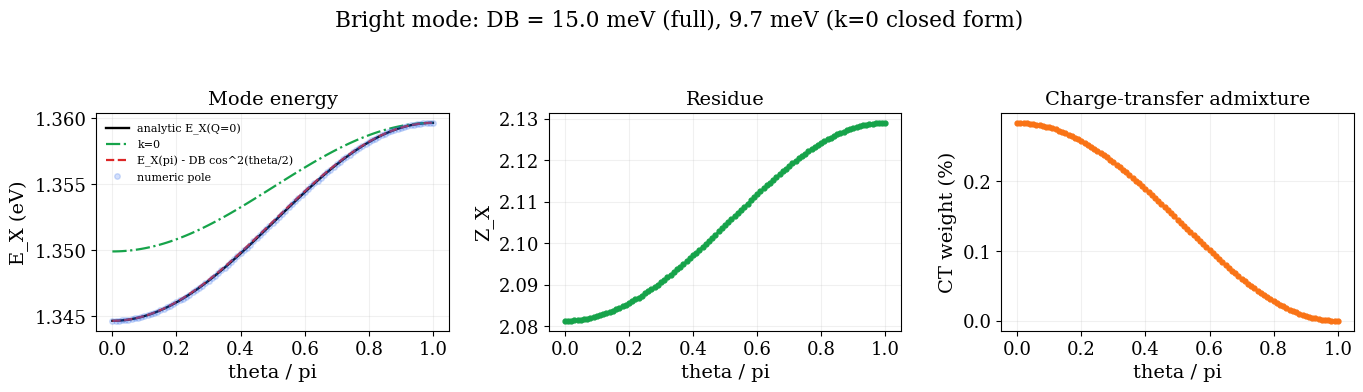

In [61]:
fig, axs = subplots(1, 3, figsize=(14.0, 4.0))

axs[1].plot(θs_sweep ./ π, EXs_ana, "-", lw=1.7, color="black", label="analytic E_X(Q=0)")
axs[1].plot(θs_sweep ./ π, EX_k0 .+ offset_k0, "-.", lw=1.6, color="#16a34a",
            label="k=0") 
    #: E0 - Vavg - sqrt(dV^2 + J+^2)  (+offset)")
axs[1].plot(θs_sweep ./ π, EX_quad, "--", lw=1.6, color="#dc2626",
            label="E_X(pi) - DB cos^2(theta/2)")
axs[1].plot(θs_sweep ./ π, EXs, "o", ms=4,alpha =0.2, color="#2563eb", label="numeric pole")
# axs[1].plot(θs_sweep ./ π, edges, ls=":", lw=1.2, color="gray", label="continuum edge")
axs[1].set_xlabel("theta / pi")
axs[1].set_ylabel("E_X (eV)")
axs[1].set_title("Mode energy")
axs[1].grid(alpha=0.18)
axs[1].legend(frameon=false, fontsize=8, loc="upper left")

axs[2].plot(θs_sweep ./ π, ZXs, "-o", ms=3.5, lw=1.4, color="#16a34a")
axs[2].set_xlabel("theta / pi")
axs[2].set_ylabel("Z_X")
axs[2].set_title("Residue")
axs[2].grid(alpha=0.18)

axs[3].plot(θs_sweep ./ π, 100 .* CTs, "-o", ms=3.5, lw=1.4, color="#f97316")
axs[3].set_xlabel("theta / pi")
axs[3].set_ylabel("CT weight (%)")
axs[3].set_title("Charge-transfer admixture")
axs[3].grid(alpha=0.18)

fig.suptitle(@sprintf("Bright mode: DB = %.1f meV (full), %.1f meV (k=0 closed form)",
                      1e3 * ΔB, 1e3 * (EX_k0[end] - EX_k0[1])))
fig.tight_layout(rect=(0, 0, 1, 0.93))

## Exciton dispersion $E_X(Q)$

The good momentum quantum number of the exciton is the **center-of-mass momentum $Q$**, not the relative momentum $k$ (which is summed inside the bubble and only defines the internal wavefunction $\phi(k)$). At fixed $Q$ the electron carries $k+Q$ and the hole $k$; for the cosine bands the two dispersions combine exactly,

$$-2\gamma_c\cos(k+Q)-2\gamma_v\cos k=-R(Q)\cos(k+\varphi),\qquad
R(Q)=2\sqrt{\gamma_c^2+\gamma_v^2+2\gamma_c\gamma_v\cos Q},$$

so the pair band at fixed $Q$ keeps its center $E_b+A$ but its half-width shrinks from $A=R(0)$ to $R(Q)$. The $k$-integrated pair propagator below the band is then the same closed form with $A\to R(Q)$ in the radicand, and the dispersion is the lowest root of

$$F_s(\Omega,\theta;Q)=1+\bar V[g_-+g_+]+V_{\rm intra}V_{\rm inter}g_-g_+=0,\qquad
g_\mp=-\left[(E_0\mp J_+ + A-\Omega)^2-R(Q)^2\right]^{-1/2}.$$

In the single-channel limit (exact at $\theta=\pi$) this is fully closed:

$$E_X(Q)=E_b+A-\sqrt{R(Q)^2+V_{\rm intra}^2}.$$

Note there is **no sum over $Q$** to get "the" exciton energy: each $Q$ is an independent eigenstate. The optical line is $E_X(Q\approx0)$ (photon momentum), which is exactly the curve in Figure 1. Sums over $Q$ only appear later, in thermal occupations or in loop diagrams where excitons at all $Q$ enter as virtual intermediate states (e.g. scattering with magnons of momentum $q$, which connects $Q=0\to Q=q$).

For $\gamma_c=\gamma_v$, $R(\pi)=2|\gamma_c-\gamma_v|=0$: the exciton band flattens at the zone boundary, and its total bandwidth $\sqrt{A^2+V^2}-V$ is much smaller than the electron-hole continuum bandwidth $A$ — the exciton is heavy.

Q=0 consistency with Figure 1: |E_X(Q=0) - EXs_ana| = 0.00e+00 eV (θ=π), 0.00e+00 eV (θ=0)
θ=π: max |two-channel root - closed form| over Q: 8.88e-16 eV
exciton bandwidth: 0.6324 eV   vs e-h continuum-bottom bandwidth: 1.6000 eV


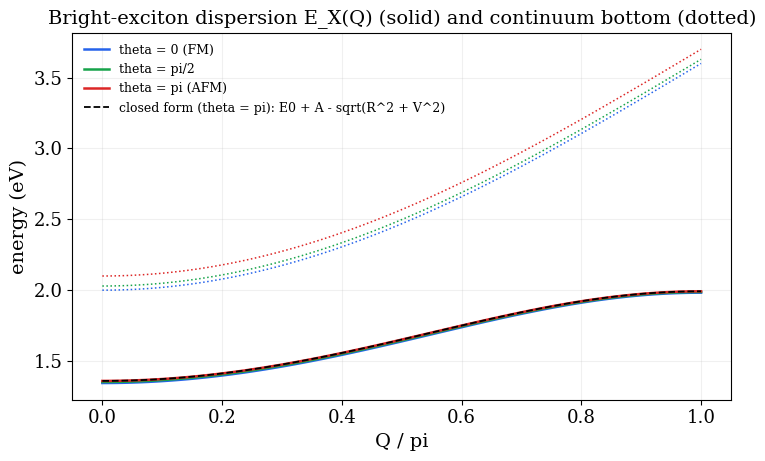

In [54]:
# -----------------------------
# Exciton dispersion E_X(Q;θ): analytic root of F_s at each center-of-mass Q
# -----------------------------
Qs = collect(range(0.0, stop=π, length=121))
θ_disp = [0.0, π/2, Float64(π)]
θ_disp_labels = ["theta = 0 (FM)", "theta = pi/2", "theta = pi (AFM)"]
θ_disp_colors = ["#2563eb", "#16a34a", "#dc2626"]

EXQ = [EX_analytic(θ_disp[j]; Q=Qs[i]) for i in eachindex(Qs), j in eachindex(θ_disp)]
cont_bottom = [E0_pair() - abs(J_plus(θ_disp[j])) + A_pair() - R_pair(Qs[i])
               for i in eachindex(Qs), j in eachindex(θ_disp)]

# Single-channel closed form at θ = π (channels decoupled): exact there.
EXQ_closed = [E0_pair() + A_pair() - sqrt(R_pair(Q)^2 + V_intra^2) for Q in Qs]

@printf("Q=0 consistency with Figure 1: |E_X(Q=0) - EXs_ana| = %.2e eV (θ=π), %.2e eV (θ=0)\n",
        abs(EXQ[1, 3] - EXs_ana[end]), abs(EXQ[1, 1] - EXs_ana[1]))
@printf("θ=π: max |two-channel root - closed form| over Q: %.2e eV\n",
        maximum(abs.(EXQ[:, 3] .- EXQ_closed)))
@printf("exciton bandwidth: %.4f eV   vs e-h continuum-bottom bandwidth: %.4f eV\n",
        EXQ[end, 3] - EXQ[1, 3], cont_bottom[end, 3] - cont_bottom[1, 3])

fig, ax = subplots(figsize=(7.6, 4.8))
for j in eachindex(θ_disp)
    ax.plot(Qs ./ π, EXQ[:, j], "-", lw=1.8, color=θ_disp_colors[j], label=θ_disp_labels[j])
    ax.plot(Qs ./ π, cont_bottom[:, j], ls=":", lw=1.1, color=θ_disp_colors[j])
end
ax.plot(Qs ./ π, EXQ_closed, "--", lw=1.3, color="black",
        label="closed form (theta = pi): E0 + A - sqrt(R^2 + V^2)")
ax.set_xlabel("Q / pi")
ax.set_ylabel("energy (eV)")
ax.set_title("Bright-exciton dispersion E_X(Q) (solid) and continuum bottom (dotted)")
ax.grid(alpha=0.18)
ax.legend(frameon=false, fontsize=9, loc="upper left")
fig.tight_layout()

## Mode bubble and the propagator that remains

Project everything on the (frozen, $\Omega$-independent) mode vector:

$$\Pi_X(\Omega)=\langle X|\Pi_s(\Omega)|X\rangle,\qquad
D_X(\Omega)=\langle X|D^R_s(\Omega)|X\rangle,\qquad
D^R_s=[V_s^{-1}-\Pi_s]^{-1}.$$

Two single-mode approximations are compared against the exact projection $D_X$:

- **single-pole**: $Z_X/(\Omega-E_X+i\eta)$ — the boson that survives;
- **scalar BSE**: $[1/V_X-\Pi_X(\Omega)]^{-1}$ with $V_X=\langle X|V_s|X\rangle$ — the BSE rebuilt from the **mode bubble alone**, dropping the off-mode channel mixing.

Their agreement with $D_X$ quantifies how cleanly the bright mode decouples from the CT channel. The bottom row shows the graphical pole condition: ${\rm Re}\,\Pi_X(\Omega)$ crossing $1/V_X$ at $\Omega=E_X$.

In [55]:
# -----------------------------
# Mode-projected objects on the frequency grid
# -----------------------------
function mode_objects(mode; Ωs=Ωs, η=ηΩ)
    ΠX = ComplexF64[mode.X' * Πs(mode.data, Ω; η=η) * mode.X for Ω in Ωs]
    DX = ComplexF64[mode.X' * inv(Vinv_s - Πs(mode.data, Ω; η=η)) * mode.X for Ω in Ωs]
    Dpole = ComplexF64[mode.Z / (Ω - mode.EX + 1im * η) for Ω in Ωs]
    VX = real(mode.X' * V_s * mode.X)
    Dscalar = ComplexF64[1 / (1 / VX - ΠX[i]) for i in eachindex(Ωs)]
    return (; ΠX, DX, Dpole, Dscalar, VX)
end

θ_show = [0.0, π/2, Float64(π)]
θ_show_labels = ["theta = 0 (FM)", "theta = pi/2", "theta = pi (AFM)"]
show_modes = [exciton_mode(θ) for θ in θ_show]
show_objs = [mode_objects(m) for m in show_modes]

for (i, m) in enumerate(show_modes)
    o = show_objs[i]
    A_DX = -2 .* imag.(o.DX)
    ipk = argmax(A_DX)
    @printf("%-16s peak at Ω=%.4f (EX=%.4f)  V_X=%.4f  heights: proj=%.1f pole=%.1f scalar=%.1f\n",
            θ_show_labels[i], Ωs[ipk], m.EX, o.VX,
            A_DX[ipk], maximum(-2 .* imag.(o.Dpole)), maximum(-2 .* imag.(o.Dscalar)))
end

theta = 0 (FM)   peak at Ω=1.3453 (EX=1.3447)  V_X=-1.7051  heights: proj=818.9 pole=818.9 scalar=836.9
theta = pi/2     peak at Ω=1.3524 (EX=1.3521)  V_X=-1.7065  heights: proj=838.9 pole=838.9 scalar=844.1
theta = pi (AFM) peak at Ω=1.3594 (EX=1.3596)  V_X=-1.7080  heights: proj=849.8 pole=849.8 scalar=849.8


## Figure 2: single-mode propagator versus exact projection

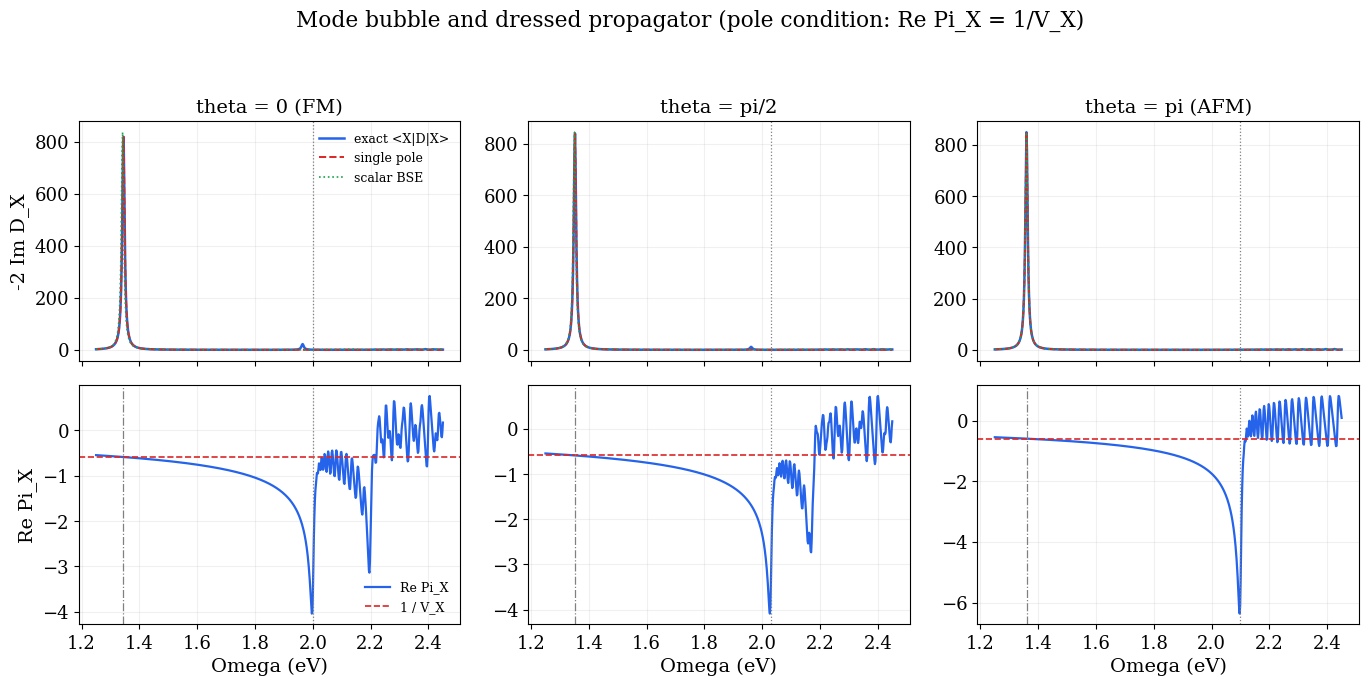

In [56]:
fig, axs = subplots(2, 3, figsize=(14.0, 7.0), sharex=true)
for i in eachindex(θ_show)
    m = show_modes[i]; o = show_objs[i]

    ax = axs[1, i]
    ax.plot(Ωs, -2 .* imag.(o.DX), lw=1.8, color="#2563eb", label="exact <X|D|X>")
    ax.plot(Ωs, -2 .* imag.(o.Dpole), lw=1.4, ls="--", color="#dc2626", label="single pole")
    ax.plot(Ωs, -2 .* imag.(o.Dscalar), lw=1.2, ls=":", color="#16a34a", label="scalar BSE")
    ax.axvline(m.cont_min, color="gray", lw=0.9, ls=":")
    ax.set_title(θ_show_labels[i])
    ax.set_ylabel(i == 1 ? "-2 Im D_X" : "")
    ax.grid(alpha=0.18)
    i == 1 && ax.legend(frameon=false, fontsize=9)

    ax = axs[2, i]
    ax.plot(Ωs, real.(o.ΠX), lw=1.6, color="#2563eb", label="Re Pi_X")
    ax.axhline(1 / o.VX, color="#dc2626", lw=1.2, ls="--", label="1 / V_X")
    ax.axvline(m.EX, color="gray", lw=0.9, ls="-.")
    ax.axvline(m.cont_min, color="gray", lw=0.9, ls=":")
    ax.set_xlabel("Omega (eV)")
    ax.set_ylabel(i == 1 ? "Re Pi_X" : "")
    ax.grid(alpha=0.18)
    i == 1 && ax.legend(frameon=false, fontsize=9)
end
fig.suptitle("Mode bubble and dressed propagator (pole condition: Re Pi_X = 1/V_X)")
fig.tight_layout(rect=(0, 0, 1, 0.94))

## Figure 3: angle-resolved single-mode spectrum

$$A_X(\Omega,\theta)=-2\,{\rm Im}\,\langle X(\theta)|D^R_s(\Omega;\theta)|X(\theta)\rangle,$$

with the pole trajectory $E_X(\theta)$ overlaid. This is the exciton band versus magnetic angle: the object whose derivative $\partial E_X/\partial\theta\propto\sin\theta$ sets the exciton-magnon coupling (maximal at $\theta=\pi/2$, vanishing in both collinear states).

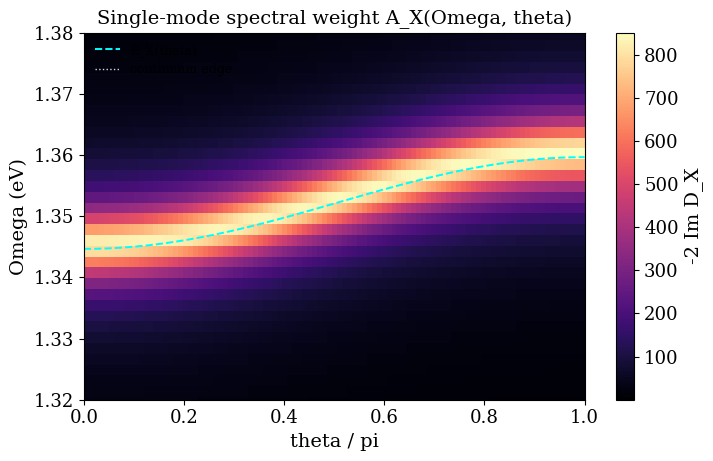

In [57]:
A_X = zeros(NΩ, Nθ)
for (iθ, m) in enumerate(modes)
    o = mode_objects(m)
    A_X[:, iθ] .= -2 .* imag.(o.DX)
end

fig, ax = subplots(figsize=(7.4, 4.8))
extent = (minimum(θs_sweep) / π, maximum(θs_sweep) / π, minimum(Ωs), maximum(Ωs))
# NOTE: never name this variable `im` -- that shadows Julia's imaginary unit
# and breaks every later `1im` (e.g. inside Πs) on the next cell run.
img = ax.imshow(A_X, origin="lower", aspect="auto", extent=extent, cmap="magma")
ax.plot(θs_sweep ./ π, EXs, color="cyan", lw=1.4, ls="--", label="E_X(theta)")
ax.plot(θs_sweep ./ π, edges, color="#d8d8d8", lw=1.0, ls=":", label="continuum edge")
ax.set_xlabel("theta / pi")
ax.set_ylabel("Omega (eV)")
ax.set_title("Single-mode spectral weight A_X(Omega, theta)")
ax.set_ylim(1.32, 1.38)
ax.legend(frameon=false, fontsize=9, loc="upper left")
cbar = fig.colorbar(img, ax=ax)
cbar.set_label("-2 Im D_X")
fig.tight_layout()

## Scope and next steps

What this notebook establishes:

- The bright A exciton of the calibrated model is a **clean single boson**: the single-pole form $Z_X/(\Omega-E_X+i\eta)$ is indistinguishable from the exact mode projection near resonance, and even the scalar BSE built from the mode bubble alone is accurate to a few percent. Off-mode (CT-channel) mixing is negligible at these couplings.
- $E_X(\theta)$ follows the quadratic law $-\Delta_B\cos^2(\theta/2)$ with $\Delta_B\simeq15$ meV, and $Z_X$, the CT weight vary smoothly with $\theta$.

How to use it downstream:

- In the spin-susceptibility (`StaticSpinSucep`) and light-torque (`LightInducedExcitonTorque`) pipelines, the channel-space $D_{\mu\nu}$ can be replaced by $Z_X X_\mu X_\nu^*/(\Omega-E_X+i\eta)$: every contraction with the vertices $\Lambda$ becomes scalar, and the exciton-magnetization coupling reduces to $g\propto\partial E_X/\partial\theta\propto\sin\theta$ — maximal at $\theta=\pi/2$, which is exactly the configuration where arXiv:2409.18501 sees the largest magnon-mediated exciton interaction.

Caveats kept out of the single-mode description:

- the mode basis rotates with $\theta$: dynamic problems acquire connection terms $\langle X|\partial_\theta X\rangle$ (mixing with the CT pole and the dark partner) neglected here;
- $Z_X(\theta)$ must accompany $E_X(\theta)$ in any intensity/coupling estimate;
- the dark partner (antisymmetric sector) and the CT poles near the continuum edge are excluded by construction;
- the experimental B exciton (1.77 eV, 80 meV shift) needs a second valence band; the ab-initio dark>bright shift ordering needs a channel-dependent $V$.